In [2]:
import os
os.chdir("/Users/alimurad/Desktop/projects/rag-pgvector")

from rag_pgvector.src.utils.utils import notebook_line_magic
notebook_line_magic()

In [ ]:
from dotenv import load_dotenv
load_dotenv()

from rag_pgvector.src.utils.utils import get_token_provider
from rag_pgvector.src.models.embeddings import generate_embedding
from rag_pgvector.src.data.query_pg import query_similar_chunks
from rag_pgvector.src.models.chat_completion import chat_completion


def get_response(query: str, temperature: float=1.0, top_k: int=5) -> str:
    """
    Get a response from the chat completion model based on the query.
    Parameters:
    query (str): The user query.
    Returns:
    str: The response from the chat completion model.
    """
    token_provider = get_token_provider()
    emb = generate_embedding(
        token_provider, 
        dimensions=786,
        text=query
    )
    semantic_chunks = query_similar_chunks(
        embedding=emb,
        top_k=top_k
    )
    context = "\n\n".join(semantic_chunks["text"].dropna().astype(str))
    response = chat_completion(
        token_provider=token_provider,
        user_prompt=query,
        context=context,
        temperature=temperature
    )

    return response, context

In [38]:
query = "Give me a side by side comparison of the earnings from this and the previous year?"
response, context = get_response(query=query, temperature=0.7, top_k=5)

In [58]:
## run evals over temperature and top_k
from rag_pgvector.src.metrics.eval import run_metrics_evaluation

model_param_grid = {
    "temperature": [0.2, 0.8],
    "top_k": [3, 5, 7]
}
results = run_metrics_evaluation(model_param_grid=model_param_grid)

In [73]:
results.to_csv("results.csv")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['figure.figsize'] = [12, 6]

results_summary = results.pivot_table(
    index=["temperature", "top_k"],
    values=[
        "answer_relevance",
        "context_relevance",
        "faithfulness",
        "hallucination_risk",
        # "response_time_seconds"
    ],
    aggfunc="mean",
).round(3)

In [94]:
results.pivot_table(
    index=["temperature", "top_k"],
    values=[
        "answer_relevance",
        "context_relevance",
        "faithfulness",
        "hallucination_risk",
        "response_time_seconds"
    ],
    aggfunc="mean",
).round(3)

answer_relevance  context_relevance  faithfulness  \
temperature top_k                                                      
0.2         3                 0.632              0.747         0.548   
            5                 0.731              0.737         0.624   
            7                 0.783              0.729         0.663   
0.8         3                 0.607              0.747         0.530   
            5                 0.684              0.737         0.584   
            7                 0.758              0.730         0.640   

                   hallucination_risk  response_time_seconds  
temperature top_k                                             
0.2         3                   0.452                  4.737  
            5                   0.376                  4.918  
            7                   0.337                  4.761  
0.8         3                   0.470                  4.402  
            5                   0.416                  4.904  
            7                   0.360                  4.857

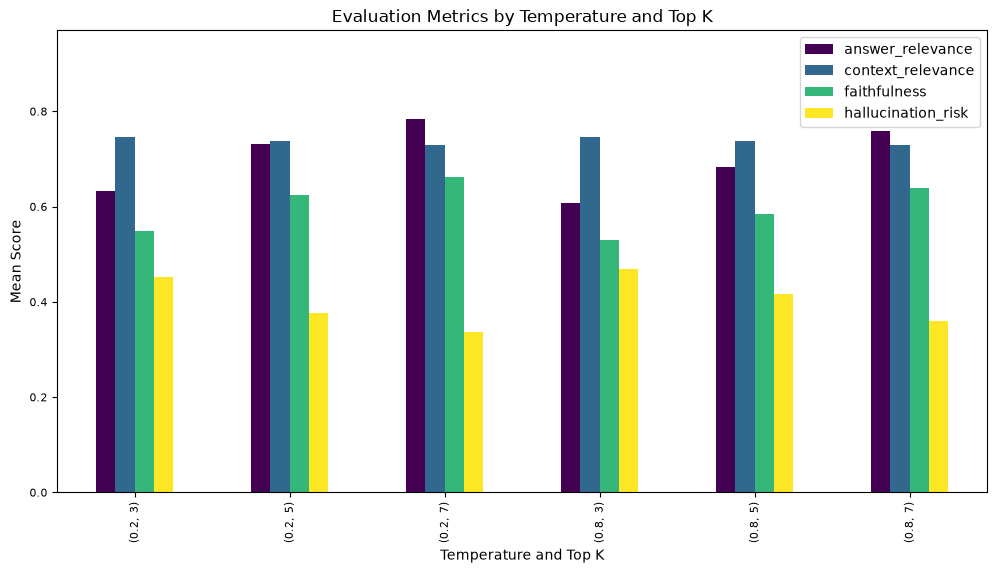

In [97]:
results_summary.plot(
    kind="bar", figsize=(12, 6), 
    title="Evaluation Metrics by Temperature and Top K", ylabel="Mean Score", xlabel="Temperature and Top K",
    colormap="viridis",
    ylim=(0, 0.97),
    position=0.5,
    fontsize=8,   
)
plt.show()